## Train 1
### baseline

開始訓練 Agent...
Episode: 200/1000, Average Reward: -526.43, Epsilon: 0.37
Episode: 400/1000, Average Reward: -51.98, Epsilon: 0.13
Episode: 600/1000, Average Reward: 231.79, Epsilon: 0.05
Episode: 800/1000, Average Reward: 347.20, Epsilon: 0.02
Episode: 1000/1000, Average Reward: 404.43, Epsilon: 0.01
訓練完成！


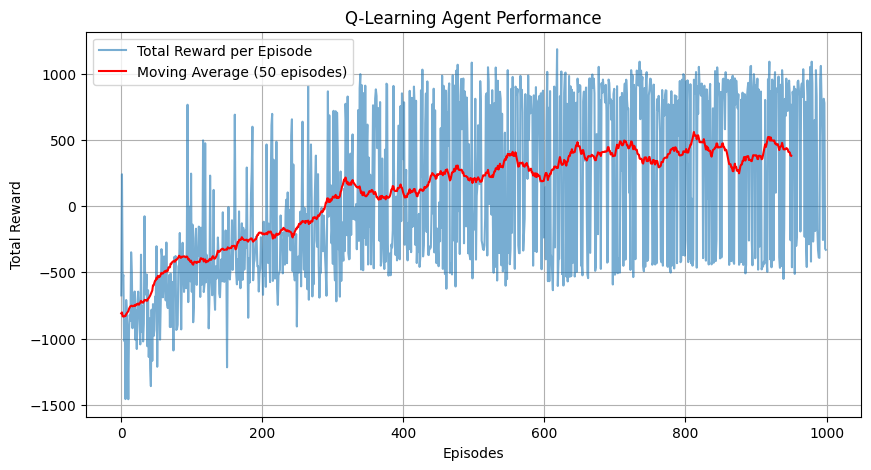

In [ ]:
import numpy as np
import random
import matplotlib.pyplot as plt

# ==========================================
# 1. 環境定義 (Environment)
# ==========================================
class SmartGreenhouseEnv:
    def __init__(self):
        self.state_space = [3, 3, 3] # 濕度, 溫度, 光照
        self.action_space = 7
        self.state = [1, 1, 1]

    def reset(self):
        self.state = [random.randint(0, 2) for _ in range(3)]
        return self._get_state_index()

    def step(self, action):
        self._update_state(action)
        reward = self._calculate_reward(action)
        done = False
        return self._get_state_index(), reward, done

    def _update_state(self, action):
        moisture, temp, light = self.state
        if action == 1:   moisture = min(2, moisture + 1)
        elif action == 3: temp = min(2, temp + 1)
        elif action == 5: light = min(2, light + 1)
        elif action == 6: light = max(0, light - 1)

        if random.random() < 0.2:
            moisture = max(0, moisture - 1)

        self.state = [moisture, temp, light]

    def _calculate_reward(self, action):
        reward = 0
        moisture, temp, light = self.state

        if moisture == 1: reward += 10
        elif moisture == 0: reward -= 20

        if temp == 1: reward += 10
        elif temp == 0 or temp == 2: reward -= 15

        if light == 1: reward += 5

        if action == 1: reward -= 2
        if action == 3: reward -= 5

        return reward

    def _get_state_index(self):
        m, t, l = self.state
        return m * 9 + t * 3 + l

# ==========================================
# 2. 代理人定義 (Q-Learning Agent)
# ==========================================
class QLearningAgent:
    def __init__(self, state_size, action_size, learning_rate=0.1, discount_factor=0.9, epsilon=1.0, epsilon_decay=0.995, epsilon_min=0.01):
        self.state_size = state_size
        self.action_size = action_size
        self.lr = learning_rate
        self.gamma = discount_factor
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.epsilon_min = epsilon_min
        self.q_table = np.zeros((state_size, action_size))

    def choose_action(self, state):
        if np.random.rand() < self.epsilon:
            return np.random.randint(self.action_size)
        return np.argmax(self.q_table[state])

    def learn(self, state, action, reward, next_state):
        best_next_action = np.argmax(self.q_table[next_state])
        td_target = reward + self.gamma * self.q_table[next_state][best_next_action]
        td_error = td_target - self.q_table[state][action]
        self.q_table[state][action] += self.lr * td_error

    def decay_epsilon(self):
        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay

# ==========================================
# 3. 訓練迴圈與視覺化 (Training & Visualization)
# ==========================================
env = SmartGreenhouseEnv()
state_size = 3 * 3 * 3
action_size = 7

# 初始化 Agent
agent = QLearningAgent(state_size, action_size)

episodes = 1000
max_steps = 50
rewards_history = []

print("開始訓練 Agent...")
for e in range(episodes):
    state = env.reset()
    total_reward = 0

    for step in range(max_steps):
        action = agent.choose_action(state)
        next_state, reward, done = env.step(action)
        agent.learn(state, action, reward, next_state)

        state = next_state
        total_reward += reward

    agent.decay_epsilon()
    rewards_history.append(total_reward)

    if (e + 1) % 200 == 0:
        avg_reward = np.mean(rewards_history[-200:])
        print(f"Episode: {e+1}/{episodes}, Average Reward: {avg_reward:.2f}, Epsilon: {agent.epsilon:.2f}")

print("訓練完成！")

# 繪製學習曲線
plt.figure(figsize=(10, 5))
plt.plot(rewards_history, label='Total Reward per Episode', alpha=0.6)
# 加上移動平均線讓趨勢更明顯
moving_avg = np.convolve(rewards_history, np.ones(50)/50, mode='valid')
plt.plot(moving_avg, color='red', label='Moving Average (50 episodes)')
plt.title('Q-Learning Agent Performance')
plt.xlabel('Episodes')
plt.ylabel('Total Reward')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# ====================================================================
# 測試階段 (Test Phase / Evaluation Phase)
# ====================================================================
import matplotlib.pyplot as plt
import numpy as np

print("開始進入 HW1 Q-Learning 模型測試階段 (Test Phase)...")

test_episodes = 10
test_rewards = []
max_test_steps = 50 # 與訓練時保持一致

for ep in range(test_episodes):
    state = env.reset()
    ep_reward = 0

    for _ in range(max_test_steps):
        # 選擇目前狀態下 Q 值最大的最優動作
        action = np.argmax(agent.q_table[state])

        # 執行動作
        next_state, reward, done = env.step(action)
        ep_reward += reward
        state = next_state

    test_rewards.append(ep_reward)
    print(f"Test Episode {ep+1}/{test_episodes} - Total Reward: {ep_reward:.2f}")

print(f"\n[測試結論] {test_episodes} 回合測試平均得分: {np.mean(test_rewards):.2f}")

# -------------------------------------------------------------
# 繪製測試圖表
# -------------------------------------------------------------
plt.figure(figsize=(8, 4))
plt.bar(range(1, test_episodes + 1), test_rewards, color='royalblue', alpha=0.8, edgecolor='black')
plt.axhline(y=np.mean(test_rewards), color='red', linestyle='--', linewidth=2, label=f'Avg Reward ({np.mean(test_rewards):.1f})')
plt.title('HW1 Test Phase Performance (Epsilon = 0)', fontsize=12)
plt.xlabel('Evaluation Episodes')
plt.ylabel('Total Reward')
plt.xticks(range(1, test_episodes + 1))
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Train 2
###

開始訓練 Agent...
Episode: 200/1000, Average Reward: -746.98, Epsilon: 0.37
Episode: 400/1000, Average Reward: -200.32, Epsilon: 0.13
Episode: 600/1000, Average Reward: 44.60, Epsilon: 0.05
Episode: 800/1000, Average Reward: 236.72, Epsilon: 0.02
Episode: 1000/1000, Average Reward: 271.30, Epsilon: 0.01
訓練完成！


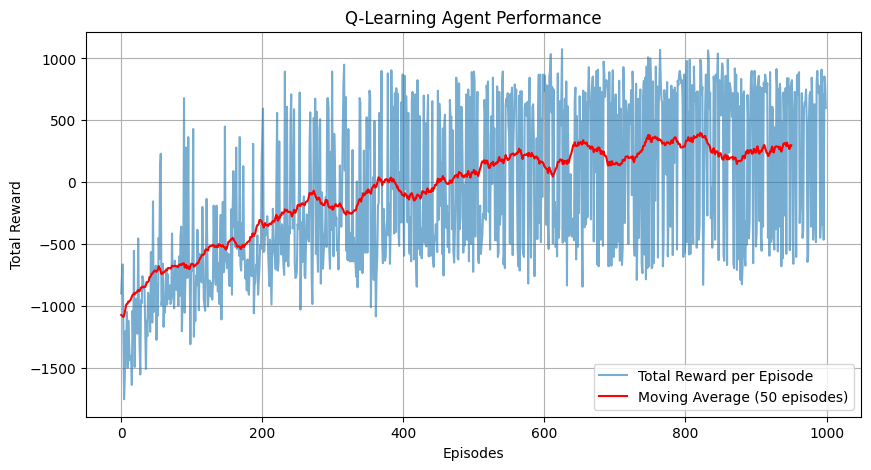

In [ ]:
import numpy as np
import random
import matplotlib.pyplot as plt

# ==========================================
# 1. 環境定義 (Environment)
# ==========================================
class SmartGreenhouseEnv:
    def __init__(self):
        self.state_space = [3, 3, 3] # 濕度, 溫度, 光照
        self.action_space = 7
        self.state = [1, 1, 1]

    def reset(self):
        self.state = [random.randint(0, 2) for _ in range(3)]
        return self._get_state_index()

    def step(self, action):
        self._update_state(action)
        reward = self._calculate_reward(action)
        done = False
        return self._get_state_index(), reward, done

    def _update_state(self, action):
        moisture, temp, light = self.state
        if action == 1:   moisture = min(2, moisture + 1)
        elif action == 3: temp = min(2, temp + 1)
        elif action == 5: light = min(2, light + 1)
        elif action == 6: light = max(0, light - 1)

        if random.random() < 0.2:
            moisture = max(0, moisture - 1)

        self.state = [moisture, temp, light]

    def _calculate_reward(self, action):
        reward = 0
        moisture, temp, light = self.state

        # 1. 植物健康獎勵 (維持不變)
        if moisture == 1: reward += 10
        elif moisture == 0: reward -= 20 # 太乾會枯萎

        if temp == 1: reward += 10
        elif temp == 0 or temp == 2: reward -= 15 # 溫度波動導致疾病

        if light == 1: reward += 5

        # 2. 成本懲罰 (★ 極端客家模式：水電費暴漲！)
        if action == 1: reward -= 15  # 水費：從原本的 -2 漲到 -15
        if action == 3: reward -= 30  # 電費：從原本的 -5 漲到 -30 (加熱器超級貴)

        return reward

    def _get_state_index(self):
        m, t, l = self.state
        return m * 9 + t * 3 + l

# ==========================================
# 2. 代理人定義 (Q-Learning Agent)
# ==========================================
class QLearningAgent:
    def __init__(self, state_size, action_size, learning_rate=0.1, discount_factor=0.9, epsilon=1.0, epsilon_decay=0.995, epsilon_min=0.01):
        self.state_size = state_size
        self.action_size = action_size
        self.lr = learning_rate
        self.gamma = discount_factor
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.epsilon_min = epsilon_min
        self.q_table = np.zeros((state_size, action_size))

    def choose_action(self, state):
        if np.random.rand() < self.epsilon:
            return np.random.randint(self.action_size)
        return np.argmax(self.q_table[state])

    def learn(self, state, action, reward, next_state):
        best_next_action = np.argmax(self.q_table[next_state])
        td_target = reward + self.gamma * self.q_table[next_state][best_next_action]
        td_error = td_target - self.q_table[state][action]
        self.q_table[state][action] += self.lr * td_error

    def decay_epsilon(self):
        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay

# ==========================================
# 3. 訓練迴圈與視覺化 (Training & Visualization)
# ==========================================
env = SmartGreenhouseEnv()
state_size = 3 * 3 * 3
action_size = 7

# 初始化 Agent
agent = QLearningAgent(state_size, action_size)

episodes = 1000
max_steps = 50
rewards_history = []

print("開始訓練 Agent...")
for e in range(episodes):
    state = env.reset()
    total_reward = 0

    for step in range(max_steps):
        action = agent.choose_action(state)
        next_state, reward, done = env.step(action)
        agent.learn(state, action, reward, next_state)

        state = next_state
        total_reward += reward

    agent.decay_epsilon()
    rewards_history.append(total_reward)

    if (e + 1) % 200 == 0:
        avg_reward = np.mean(rewards_history[-200:])
        print(f"Episode: {e+1}/{episodes}, Average Reward: {avg_reward:.2f}, Epsilon: {agent.epsilon:.2f}")

print("訓練完成！")

# 繪製學習曲線
plt.figure(figsize=(10, 5))
plt.plot(rewards_history, label='Total Reward per Episode', alpha=0.6)
# 加上移動平均線讓趨勢更明顯
moving_avg = np.convolve(rewards_history, np.ones(50)/50, mode='valid')
plt.plot(moving_avg, color='red', label='Moving Average (50 episodes)')
plt.title('Q-Learning Agent Performance')
plt.xlabel('Episodes')
plt.ylabel('Total Reward')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# ====================================================================
# 測試階段 (Test Phase / Evaluation Phase)
# ====================================================================
import matplotlib.pyplot as plt
import numpy as np

print("開始進入 HW1 Q-Learning 模型測試階段 (Test Phase)...")

test_episodes = 10
test_rewards = []
max_test_steps = 50 # 與訓練時保持一致

for ep in range(test_episodes):
    state = env.reset()
    ep_reward = 0

    for _ in range(max_test_steps):
        # 選擇目前狀態下 Q 值最大的最優動作
        action = np.argmax(agent.q_table[state])

        # 執行動作
        next_state, reward, done = env.step(action)
        ep_reward += reward
        state = next_state

    test_rewards.append(ep_reward)
    print(f"Test Episode {ep+1}/{test_episodes} - Total Reward: {ep_reward:.2f}")

print(f"\n[測試結論] {test_episodes} 回合測試平均得分: {np.mean(test_rewards):.2f}")

# -------------------------------------------------------------
# 繪製測試圖表
# -------------------------------------------------------------
plt.figure(figsize=(8, 4))
plt.bar(range(1, test_episodes + 1), test_rewards, color='royalblue', alpha=0.8, edgecolor='black')
plt.axhline(y=np.mean(test_rewards), color='red', linestyle='--', linewidth=2, label=f'Avg Reward ({np.mean(test_rewards):.1f})')
plt.title('HW1 Test Phase Performance (Epsilon = 0)', fontsize=12)
plt.xlabel('Evaluation Episodes')
plt.ylabel('Total Reward')
plt.xticks(range(1, test_episodes + 1))
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Train 3

開始訓練 Agent...
Episode: 200/1000, Average Reward: -502.44, Epsilon: 0.37
Episode: 400/1000, Average Reward: -4.53, Epsilon: 0.13
Episode: 600/1000, Average Reward: 204.78, Epsilon: 0.05
Episode: 800/1000, Average Reward: 279.30, Epsilon: 0.02
Episode: 1000/1000, Average Reward: 360.33, Epsilon: 0.01
訓練完成！


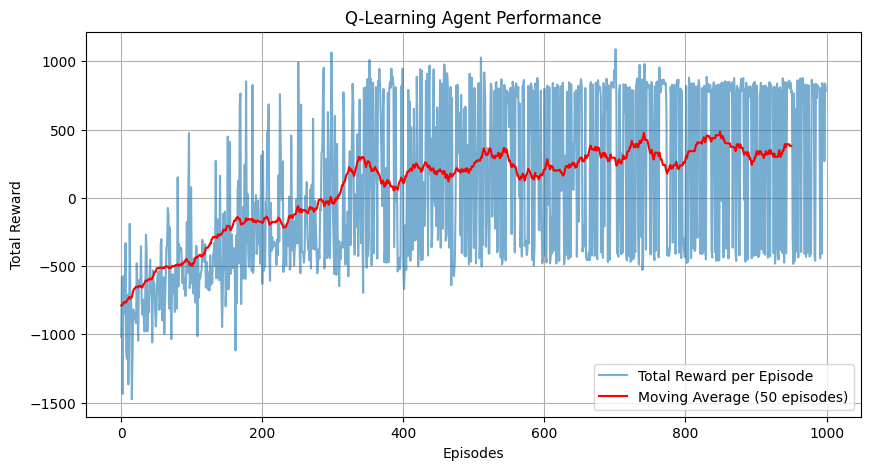

In [ ]:
import numpy as np
import random
import matplotlib.pyplot as plt

# ==========================================
# 1. 環境定義 (Environment)
# ==========================================
class SmartGreenhouseEnv:
    def __init__(self):
        self.state_space = [3, 3, 3] # 濕度, 溫度, 光照
        self.action_space = 7
        self.state = [1, 1, 1]

    def reset(self):
        self.state = [random.randint(0, 2) for _ in range(3)]
        return self._get_state_index()

    def step(self, action):
        self._update_state(action)
        reward = self._calculate_reward(action)
        done = False
        return self._get_state_index(), reward, done

    def _update_state(self, action):
        moisture, temp, light = self.state
        if action == 1:   moisture = min(2, moisture + 1)
        elif action == 3: temp = min(2, temp + 1)
        elif action == 5: light = min(2, light + 1)
        elif action == 6: light = max(0, light - 1)

        if random.random() < 0.2:
            moisture = max(0, moisture - 1)

        self.state = [moisture, temp, light]

    def _calculate_reward(self, action):
        reward = 0
        moisture, temp, light = self.state

        if moisture == 1: reward += 10
        elif moisture == 0: reward -= 20

        if temp == 1: reward += 10
        elif temp == 0 or temp == 2: reward -= 15

        if light == 1: reward += 5

        # 恢復正常水電費
        if action == 1: reward -= 2
        if action == 3: reward -= 5

        return reward

    def _get_state_index(self):
        m, t, l = self.state
        return m * 9 + t * 3 + l

# ==========================================
# 2. 代理人定義 (Q-Learning Agent)
# ==========================================
class QLearningAgent:
    def __init__(self, state_size, action_size, learning_rate=0.1, discount_factor=0.9, epsilon=1.0, epsilon_decay=0.995, epsilon_min=0.01):
        self.state_size = state_size
        self.action_size = action_size
        self.lr = learning_rate
        self.gamma = discount_factor
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.epsilon_min = epsilon_min
        self.q_table = np.zeros((state_size, action_size))

    def choose_action(self, state):
        if np.random.rand() < self.epsilon:
            return np.random.randint(self.action_size)
        return np.argmax(self.q_table[state])

    def learn(self, state, action, reward, next_state):
        best_next_action = np.argmax(self.q_table[next_state])
        td_target = reward + self.gamma * self.q_table[next_state][best_next_action]
        td_error = td_target - self.q_table[state][action]
        self.q_table[state][action] += self.lr * td_error

    def decay_epsilon(self):
        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay

# ==========================================
# 3. 訓練迴圈與視覺化 (Training & Visualization)
# ==========================================
env = SmartGreenhouseEnv()
state_size = 3 * 3 * 3
action_size = 7

# 原本是：agent = QLearningAgent(state_size, action_size)
# 改成下面這樣：
agent = QLearningAgent(state_size, action_size, discount_factor=0.1)

episodes = 1000
max_steps = 50
rewards_history = []

print("開始訓練 Agent...")
for e in range(episodes):
    state = env.reset()
    total_reward = 0

    for step in range(max_steps):
        action = agent.choose_action(state)
        next_state, reward, done = env.step(action)
        agent.learn(state, action, reward, next_state)

        state = next_state
        total_reward += reward

    agent.decay_epsilon()
    rewards_history.append(total_reward)

    if (e + 1) % 200 == 0:
        avg_reward = np.mean(rewards_history[-200:])
        print(f"Episode: {e+1}/{episodes}, Average Reward: {avg_reward:.2f}, Epsilon: {agent.epsilon:.2f}")

print("訓練完成！")

# 繪製學習曲線
plt.figure(figsize=(10, 5))
plt.plot(rewards_history, label='Total Reward per Episode', alpha=0.6)
# 加上移動平均線讓趨勢更明顯
moving_avg = np.convolve(rewards_history, np.ones(50)/50, mode='valid')
plt.plot(moving_avg, color='red', label='Moving Average (50 episodes)')
plt.title('Q-Learning Agent Performance')
plt.xlabel('Episodes')
plt.ylabel('Total Reward')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# ====================================================================
# 測試階段 (Test Phase / Evaluation Phase)
# ====================================================================
import matplotlib.pyplot as plt
import numpy as np

print("開始進入 HW1 Q-Learning 模型測試階段 (Test Phase)...")

test_episodes = 10
test_rewards = []
max_test_steps = 50 # 與訓練時保持一致

for ep in range(test_episodes):
    state = env.reset()
    ep_reward = 0

    for _ in range(max_test_steps):
        # 選擇目前狀態下 Q 值最大的最優動作
        action = np.argmax(agent.q_table[state])

        # 執行動作
        next_state, reward, done = env.step(action)
        ep_reward += reward
        state = next_state

    test_rewards.append(ep_reward)
    print(f"Test Episode {ep+1}/{test_episodes} - Total Reward: {ep_reward:.2f}")

print(f"\n[測試結論] {test_episodes} 回合測試平均得分: {np.mean(test_rewards):.2f}")

# -------------------------------------------------------------
# 繪製測試圖表
# -------------------------------------------------------------
plt.figure(figsize=(8, 4))
plt.bar(range(1, test_episodes + 1), test_rewards, color='royalblue', alpha=0.8, edgecolor='black')
plt.axhline(y=np.mean(test_rewards), color='red', linestyle='--', linewidth=2, label=f'Avg Reward ({np.mean(test_rewards):.1f})')
plt.title('HW1 Test Phase Performance (Epsilon = 0)', fontsize=12)
plt.xlabel('Evaluation Episodes')
plt.ylabel('Total Reward')
plt.xticks(range(1, test_episodes + 1))
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Train 4

開始訓練 Agent...
Episode: 200/1000, Average Reward: -1231.48, Epsilon: 0.37
Episode: 400/1000, Average Reward: -533.55, Epsilon: 0.13
Episode: 600/1000, Average Reward: -31.79, Epsilon: 0.05
Episode: 800/1000, Average Reward: 282.74, Epsilon: 0.02
Episode: 1000/1000, Average Reward: 451.30, Epsilon: 0.01
訓練完成！


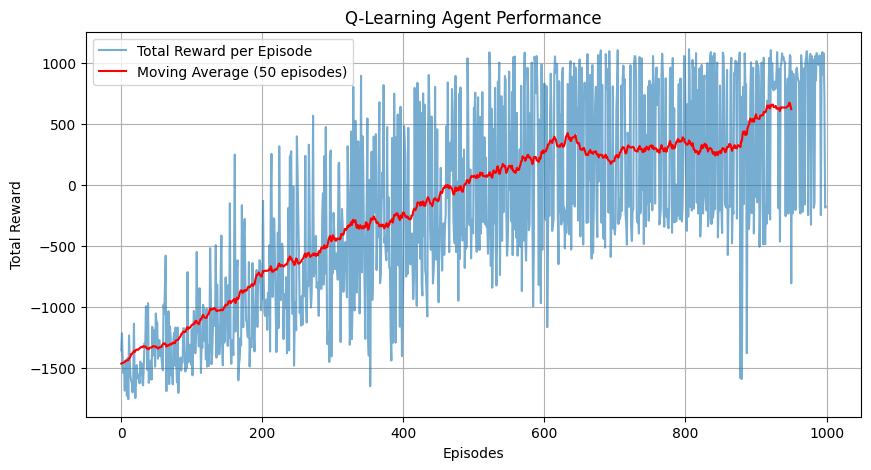

In [ ]:
import numpy as np
import random
import matplotlib.pyplot as plt

# ==========================================
# 1. 環境定義 (Environment)
# ==========================================
class SmartGreenhouseEnv:
    def __init__(self):
        self.state_space = [3, 3, 3] # 濕度, 溫度, 光照
        self.action_space = 7
        self.state = [1, 1, 1]

    def reset(self):
        self.state = [random.randint(0, 2) for _ in range(3)]
        return self._get_state_index()

    def step(self, action):
        self._update_state(action)
        reward = self._calculate_reward(action)
        done = False
        return self._get_state_index(), reward, done

    def _update_state(self, action):
        moisture, temp, light = self.state
        if action == 1:   moisture = min(2, moisture + 1)
        elif action == 3: temp = min(2, temp + 1)
        elif action == 5: light = min(2, light + 1)
        elif action == 6: light = max(0, light - 1)

        # 原本是：if random.random() < 0.2:
        # 改成下面這樣 (80% 機率掉水分)：
        if random.random() < 0.8:
            moisture = max(0, moisture - 1)

        self.state = [moisture, temp, light]

    def _calculate_reward(self, action):
        reward = 0
        moisture, temp, light = self.state

        if moisture == 1: reward += 10
        elif moisture == 0: reward -= 20

        if temp == 1: reward += 10
        elif temp == 0 or temp == 2: reward -= 15

        if light == 1: reward += 5

        if action == 1: reward -= 2
        if action == 3: reward -= 5

        return reward

    def _get_state_index(self):
        m, t, l = self.state
        return m * 9 + t * 3 + l

# ==========================================
# 2. 代理人定義 (Q-Learning Agent)
# ==========================================
class QLearningAgent:
    def __init__(self, state_size, action_size, learning_rate=0.1, discount_factor=0.9, epsilon=1.0, epsilon_decay=0.995, epsilon_min=0.01):
        self.state_size = state_size
        self.action_size = action_size
        self.lr = learning_rate
        self.gamma = discount_factor
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.epsilon_min = epsilon_min
        self.q_table = np.zeros((state_size, action_size))

    def choose_action(self, state):
        if np.random.rand() < self.epsilon:
            return np.random.randint(self.action_size)
        return np.argmax(self.q_table[state])

    def learn(self, state, action, reward, next_state):
        best_next_action = np.argmax(self.q_table[next_state])
        td_target = reward + self.gamma * self.q_table[next_state][best_next_action]
        td_error = td_target - self.q_table[state][action]
        self.q_table[state][action] += self.lr * td_error

    def decay_epsilon(self):
        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay

# ==========================================
# 3. 訓練迴圈與視覺化 (Training & Visualization)
# ==========================================
env = SmartGreenhouseEnv()
state_size = 3 * 3 * 3
action_size = 7

# 初始化 Agent
agent = QLearningAgent(state_size, action_size)

episodes = 1000
max_steps = 50
rewards_history = []

print("開始訓練 Agent...")
for e in range(episodes):
    state = env.reset()
    total_reward = 0

    for step in range(max_steps):
        action = agent.choose_action(state)
        next_state, reward, done = env.step(action)
        agent.learn(state, action, reward, next_state)

        state = next_state
        total_reward += reward

    agent.decay_epsilon()
    rewards_history.append(total_reward)

    if (e + 1) % 200 == 0:
        avg_reward = np.mean(rewards_history[-200:])
        print(f"Episode: {e+1}/{episodes}, Average Reward: {avg_reward:.2f}, Epsilon: {agent.epsilon:.2f}")

print("訓練完成！")

# 繪製學習曲線
plt.figure(figsize=(10, 5))
plt.plot(rewards_history, label='Total Reward per Episode', alpha=0.6)
# 加上移動平均線讓趨勢更明顯
moving_avg = np.convolve(rewards_history, np.ones(50)/50, mode='valid')
plt.plot(moving_avg, color='red', label='Moving Average (50 episodes)')
plt.title('Q-Learning Agent Performance')
plt.xlabel('Episodes')
plt.ylabel('Total Reward')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# ====================================================================
# 測試階段 (Test Phase / Evaluation Phase)
# ====================================================================
import matplotlib.pyplot as plt
import numpy as np

print("開始進入 HW1 Q-Learning 模型測試階段 (Test Phase)...")

test_episodes = 10
test_rewards = []
max_test_steps = 50 # 與訓練時保持一致

for ep in range(test_episodes):
    state = env.reset()
    ep_reward = 0

    for _ in range(max_test_steps):
        # 選擇目前狀態下 Q 值最大的最優動作
        action = np.argmax(agent.q_table[state])

        # 執行動作
        next_state, reward, done = env.step(action)
        ep_reward += reward
        state = next_state

    test_rewards.append(ep_reward)
    print(f"Test Episode {ep+1}/{test_episodes} - Total Reward: {ep_reward:.2f}")

print(f"\n[測試結論] {test_episodes} 回合測試平均得分: {np.mean(test_rewards):.2f}")

# -------------------------------------------------------------
# 繪製測試圖表
# -------------------------------------------------------------
plt.figure(figsize=(8, 4))
plt.bar(range(1, test_episodes + 1), test_rewards, color='royalblue', alpha=0.8, edgecolor='black')
plt.axhline(y=np.mean(test_rewards), color='red', linestyle='--', linewidth=2, label=f'Avg Reward ({np.mean(test_rewards):.1f})')
plt.title('HW1 Test Phase Performance (Epsilon = 0)', fontsize=12)
plt.xlabel('Evaluation Episodes')
plt.ylabel('Total Reward')
plt.xticks(range(1, test_episodes + 1))
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### train 5

開始訓練 Agent...
Episode: 200/1000, Average Reward: 205.34, Epsilon: 0.01
Episode: 400/1000, Average Reward: 392.84, Epsilon: 0.01
Episode: 600/1000, Average Reward: 460.95, Epsilon: 0.01
Episode: 800/1000, Average Reward: 549.66, Epsilon: 0.01
Episode: 1000/1000, Average Reward: 382.79, Epsilon: 0.01
訓練完成！


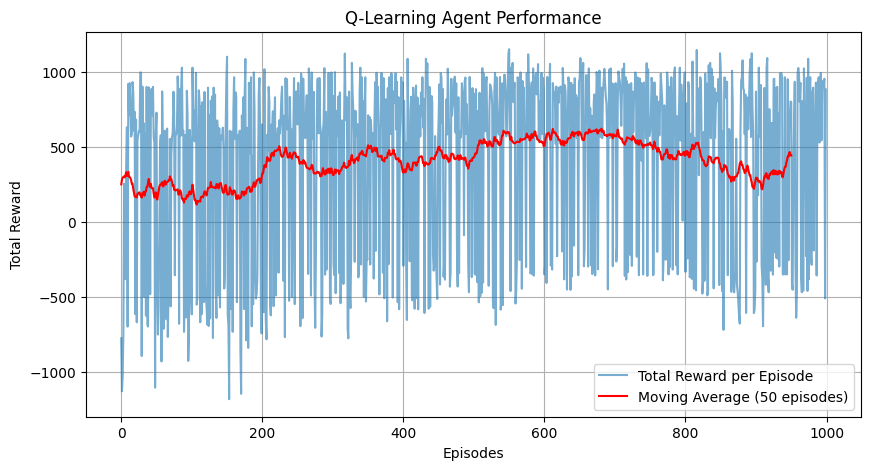

In [ ]:
import numpy as np
import random
import matplotlib.pyplot as plt

# ==========================================
# 1. 環境定義 (Environment)
# ==========================================
class SmartGreenhouseEnv:
    def __init__(self):
        self.state_space = [3, 3, 3] # 濕度, 溫度, 光照
        self.action_space = 7
        self.state = [1, 1, 1]

    def reset(self):
        self.state = [random.randint(0, 2) for _ in range(3)]
        return self._get_state_index()

    def step(self, action):
        self._update_state(action)
        reward = self._calculate_reward(action)
        done = False
        return self._get_state_index(), reward, done

    def _update_state(self, action):
        moisture, temp, light = self.state
        if action == 1:   moisture = min(2, moisture + 1)
        elif action == 3: temp = min(2, temp + 1)
        elif action == 5: light = min(2, light + 1)
        elif action == 6: light = max(0, light - 1)

        if random.random() < 0.2:
            moisture = max(0, moisture - 1)

        self.state = [moisture, temp, light]

    def _calculate_reward(self, action):
        reward = 0
        moisture, temp, light = self.state

        if moisture == 1: reward += 10
        elif moisture == 0: reward -= 20

        if temp == 1: reward += 10
        elif temp == 0 or temp == 2: reward -= 15

        if light == 1: reward += 5

        if action == 1: reward -= 2
        if action == 3: reward -= 5

        return reward

    def _get_state_index(self):
        m, t, l = self.state
        return m * 9 + t * 3 + l

# ==========================================
# 2. 代理人定義 (Q-Learning Agent)
# ==========================================
class QLearningAgent:
    def __init__(self, state_size, action_size, learning_rate=0.1, discount_factor=0.9, epsilon=1.0, epsilon_decay=0.995, epsilon_min=0.01):
        self.state_size = state_size
        self.action_size = action_size
        self.lr = learning_rate
        self.gamma = discount_factor
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.epsilon_min = epsilon_min
        self.q_table = np.zeros((state_size, action_size))

    def choose_action(self, state):
        if np.random.rand() < self.epsilon:
            return np.random.randint(self.action_size)
        return np.argmax(self.q_table[state])

    def learn(self, state, action, reward, next_state):
        best_next_action = np.argmax(self.q_table[next_state])
        td_target = reward + self.gamma * self.q_table[next_state][best_next_action]
        td_error = td_target - self.q_table[state][action]
        self.q_table[state][action] += self.lr * td_error

    def decay_epsilon(self):
        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay

# ==========================================
# 3. 訓練迴圈與視覺化 (Training & Visualization)
# ==========================================
env = SmartGreenhouseEnv()
state_size = 3 * 3 * 3
action_size = 7

# 初始化 Agent
# 修改這行：
agent = QLearningAgent(state_size, action_size, epsilon_decay=0.8)

episodes = 1000
max_steps = 50
rewards_history = []

print("開始訓練 Agent...")
for e in range(episodes):
    state = env.reset()
    total_reward = 0

    for step in range(max_steps):
        action = agent.choose_action(state)
        next_state, reward, done = env.step(action)
        agent.learn(state, action, reward, next_state)

        state = next_state
        total_reward += reward

    agent.decay_epsilon()
    rewards_history.append(total_reward)

    if (e + 1) % 200 == 0:
        avg_reward = np.mean(rewards_history[-200:])
        print(f"Episode: {e+1}/{episodes}, Average Reward: {avg_reward:.2f}, Epsilon: {agent.epsilon:.2f}")

print("訓練完成！")

# 繪製學習曲線
plt.figure(figsize=(10, 5))
plt.plot(rewards_history, label='Total Reward per Episode', alpha=0.6)
# 加上移動平均線讓趨勢更明顯
moving_avg = np.convolve(rewards_history, np.ones(50)/50, mode='valid')
plt.plot(moving_avg, color='red', label='Moving Average (50 episodes)')
plt.title('Q-Learning Agent Performance')
plt.xlabel('Episodes')
plt.ylabel('Total Reward')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# ====================================================================
# 測試階段 (Test Phase / Evaluation Phase)
# ====================================================================
import matplotlib.pyplot as plt
import numpy as np

print("開始進入 HW1 Q-Learning 模型測試階段 (Test Phase)...")

test_episodes = 10
test_rewards = []
max_test_steps = 50 # 與訓練時保持一致

for ep in range(test_episodes):
    state = env.reset()
    ep_reward = 0

    for _ in range(max_test_steps):
        # 選擇目前狀態下 Q 值最大的最優動作
        action = np.argmax(agent.q_table[state])

        # 執行動作
        next_state, reward, done = env.step(action)
        ep_reward += reward
        state = next_state

    test_rewards.append(ep_reward)
    print(f"Test Episode {ep+1}/{test_episodes} - Total Reward: {ep_reward:.2f}")

print(f"\n[測試結論] {test_episodes} 回合測試平均得分: {np.mean(test_rewards):.2f}")

# -------------------------------------------------------------
# 繪製測試圖表
# -------------------------------------------------------------
plt.figure(figsize=(8, 4))
plt.bar(range(1, test_episodes + 1), test_rewards, color='royalblue', alpha=0.8, edgecolor='black')
plt.axhline(y=np.mean(test_rewards), color='red', linestyle='--', linewidth=2, label=f'Avg Reward ({np.mean(test_rewards):.1f})')
plt.title('HW1 Test Phase Performance (Epsilon = 0)', fontsize=12)
plt.xlabel('Evaluation Episodes')
plt.ylabel('Total Reward')
plt.xticks(range(1, test_episodes + 1))
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Train 6

開始訓練 Agent...
Episode: 200/1000, Average Reward: -564.87, Epsilon: 0.37
Episode: 400/1000, Average Reward: -196.29, Epsilon: 0.13
Episode: 600/1000, Average Reward: 161.76, Epsilon: 0.05
Episode: 800/1000, Average Reward: 282.42, Epsilon: 0.02
Episode: 1000/1000, Average Reward: 332.19, Epsilon: 0.01
訓練完成！


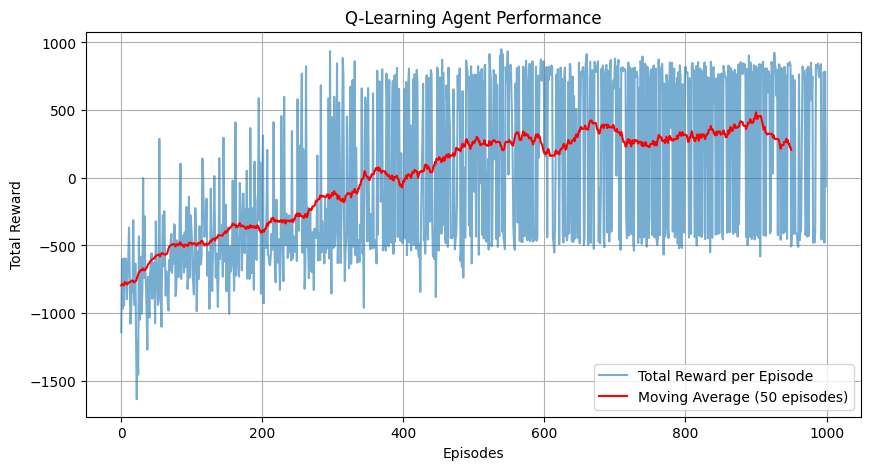

In [ ]:
import numpy as np
import random
import matplotlib.pyplot as plt

# ==========================================
# 1. 環境定義 (Environment)
# ==========================================
class SmartGreenhouseEnv:
    def __init__(self):
        self.state_space = [3, 3, 3] # 濕度, 溫度, 光照
        self.action_space = 7
        self.state = [1, 1, 1]

    def reset(self):
        self.state = [random.randint(0, 2) for _ in range(3)]
        return self._get_state_index()

    def step(self, action):
        self._update_state(action)
        reward = self._calculate_reward(action)
        done = False
        return self._get_state_index(), reward, done

    def _update_state(self, action):
        moisture, temp, light = self.state
        if action == 1:   moisture = min(2, moisture + 1)
        elif action == 3: temp = min(2, temp + 1)
        elif action == 5: light = min(2, light + 1)
        elif action == 6: light = max(0, light - 1)

        if random.random() < 0.2:
            moisture = max(0, moisture - 1)

        self.state = [moisture, temp, light]

    def _calculate_reward(self, action):
        reward = 0
        moisture, temp, light = self.state

        if moisture == 1: reward += 10
        elif moisture == 0: reward -= 20

        if temp == 1: reward += 10
        elif temp == 0 or temp == 2: reward -= 15

        if light == 1: reward += 5

        if action == 1: reward -= 2
        if action == 3: reward -= 5

        return reward

    def _get_state_index(self):
        m, t, l = self.state
        return m * 9 + t * 3 + l

# ==========================================
# 2. 代理人定義 (Q-Learning Agent)
# ==========================================
class QLearningAgent:
    def __init__(self, state_size, action_size, learning_rate=0.1, discount_factor=0.9, epsilon=1.0, epsilon_decay=0.995, epsilon_min=0.01):
        self.state_size = state_size
        self.action_size = action_size
        self.lr = learning_rate
        self.gamma = discount_factor
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.epsilon_min = epsilon_min
        self.q_table = np.zeros((state_size, action_size))

    def choose_action(self, state):
        if np.random.rand() < self.epsilon:
            return np.random.randint(self.action_size)
        return np.argmax(self.q_table[state])

    def learn(self, state, action, reward, next_state):
        best_next_action = np.argmax(self.q_table[next_state])
        td_target = reward + self.gamma * self.q_table[next_state][best_next_action]
        td_error = td_target - self.q_table[state][action]
        self.q_table[state][action] += self.lr * td_error

    def decay_epsilon(self):
        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay

# ==========================================
# 3. 訓練迴圈與視覺化 (Training & Visualization)
# ==========================================
env = SmartGreenhouseEnv()
state_size = 3 * 3 * 3
action_size = 7

# 初始化 Agent
agent = QLearningAgent(state_size, action_size, learning_rate=1.0)

episodes = 1000
max_steps = 50
rewards_history = []

print("開始訓練 Agent...")
for e in range(episodes):
    state = env.reset()
    total_reward = 0

    for step in range(max_steps):
        action = agent.choose_action(state)
        next_state, reward, done = env.step(action)
        agent.learn(state, action, reward, next_state)

        state = next_state
        total_reward += reward

    agent.decay_epsilon()
    rewards_history.append(total_reward)

    if (e + 1) % 200 == 0:
        avg_reward = np.mean(rewards_history[-200:])
        print(f"Episode: {e+1}/{episodes}, Average Reward: {avg_reward:.2f}, Epsilon: {agent.epsilon:.2f}")

print("訓練完成！")

# 繪製學習曲線
plt.figure(figsize=(10, 5))
plt.plot(rewards_history, label='Total Reward per Episode', alpha=0.6)
# 加上移動平均線讓趨勢更明顯
moving_avg = np.convolve(rewards_history, np.ones(50)/50, mode='valid')
plt.plot(moving_avg, color='red', label='Moving Average (50 episodes)')
plt.title('Q-Learning Agent Performance')
plt.xlabel('Episodes')
plt.ylabel('Total Reward')
plt.legend()
plt.grid(True)
plt.show()

開始進入 HW1 Q-Learning 模型測試階段 (Test Phase)...
Test Episode 1/10 - Total Reward: -503.00
Test Episode 2/10 - Total Reward: 758.00
Test Episode 3/10 - Total Reward: 854.00
Test Episode 4/10 - Total Reward: 787.00
Test Episode 5/10 - Total Reward: 832.00
Test Episode 6/10 - Total Reward: 727.00
Test Episode 7/10 - Total Reward: -498.00
Test Episode 8/10 - Total Reward: -510.00
Test Episode 9/10 - Total Reward: -450.00
Test Episode 10/10 - Total Reward: 718.00

[測試結論] 10 回合測試平均得分: 271.50


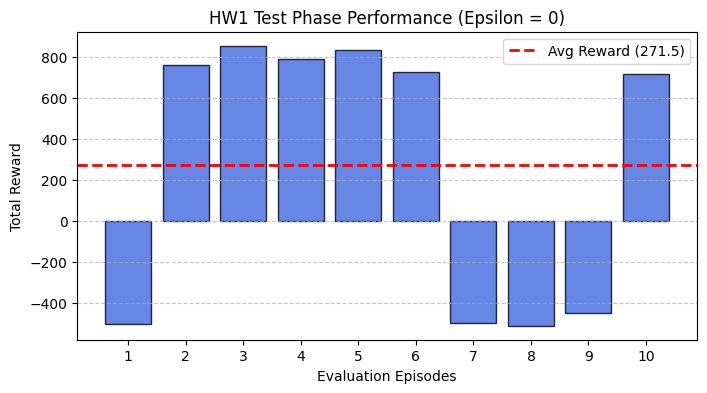

In [ ]:
# ====================================================================
# 測試階段 (Test Phase / Evaluation Phase)
# ====================================================================
import matplotlib.pyplot as plt
import numpy as np

print("開始進入 HW1 Q-Learning 模型測試階段 (Test Phase)...")

test_episodes = 10
test_rewards = []
max_test_steps = 50 # 與訓練時保持一致

for ep in range(test_episodes):
    state = env.reset()
    ep_reward = 0

    for _ in range(max_test_steps):
        # 選擇目前狀態下 Q 值最大的最優動作
        action = np.argmax(agent.q_table[state])

        # 執行動作
        next_state, reward, done = env.step(action)
        ep_reward += reward
        state = next_state

    test_rewards.append(ep_reward)
    print(f"Test Episode {ep+1}/{test_episodes} - Total Reward: {ep_reward:.2f}")

print(f"\n[測試結論] {test_episodes} 回合測試平均得分: {np.mean(test_rewards):.2f}")

# -------------------------------------------------------------
# 繪製測試圖表
# -------------------------------------------------------------
plt.figure(figsize=(8, 4))
plt.bar(range(1, test_episodes + 1), test_rewards, color='royalblue', alpha=0.8, edgecolor='black')
plt.axhline(y=np.mean(test_rewards), color='red', linestyle='--', linewidth=2, label=f'Avg Reward ({np.mean(test_rewards):.1f})')
plt.title('HW1 Test Phase Performance (Epsilon = 0)', fontsize=12)
plt.xlabel('Evaluation Episodes')
plt.ylabel('Total Reward')
plt.xticks(range(1, test_episodes + 1))
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()